In [1]:
## Requires Python 3.9 or lower for FlowCytometryTools
import glob
import os
import numpy as np
import pandas as pd
import scipy.signal
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import FlowCytometryTools
from FlowCytometryTools import FCMeasurement
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde
from collections import Counter

ip =  1/1.46

plt.style.use('styleNB.mplstyle')


# Load in data

In [2]:
# Migration track data
df = pd.read_csv('../../data/processed_2D_tracking/20250527_MDCK_filtered_tracks_compiled.csv')

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'scope', 'position', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 15:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'scope': g[5],
            'position': g[6],
            'cell': g[7],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)


df_filtered_tracks.celltype.unique()
df = df_filtered_tracks

# Flow cytometry data
files = glob.glob('../../data/flow_cytometry/20250514_MDCK/*.fcs')



In [3]:
dict_EF = {'0' : 0, 
           '3' : 1}

# Plotting - All cells (single cells and clusters)

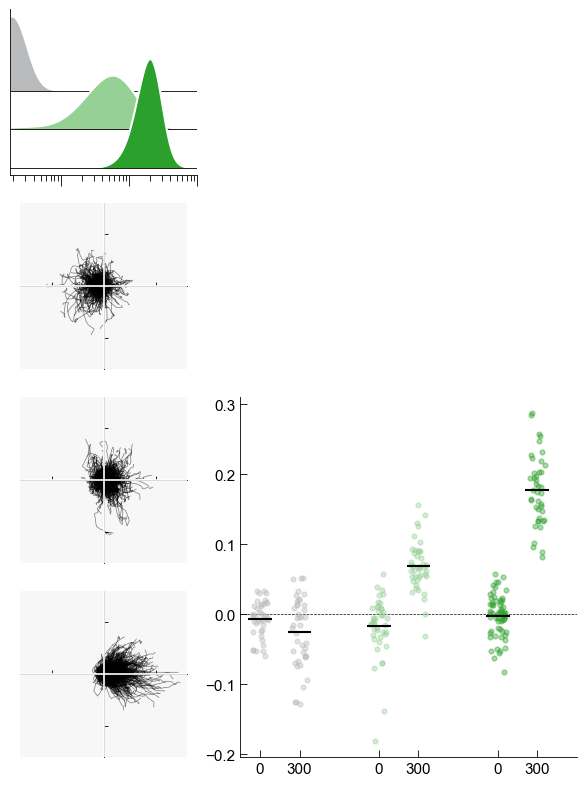

In [4]:
from matplotlib.pyplot import GridSpec
from scipy.stats import gaussian_kde
from collections import Counter

fig = plt.figure(figsize=(6,8))
gs = GridSpec(nrows=4, ncols=2,
              height_ratios=[1, 1, 1, 1],
              width_ratios=[1, 1.8])


###################################
# flow  cytometry
################################################
############################
############################
ax1 = fig.add_subplot(gs[0,0])

# Input files and labels
flow_files = [files[0], files[1], files[-1]]
# labels = ['CR02-high', 'CR01-low', 'WT-parental']
labels = ['MDCK +Galvanin-GFP\n(high expression)', 'MDCK +Galvanin-GFP\n(low expression)', 'MDCK']
colors = [(0.1725, 0.6274, 0.1725), (0.586, 0.814, 0.586), '#B8BABC']


offset = 0.75

x_shared = np.linspace(3.25, 6.6, 500)  # Shared x-grid
density_cutoff = 1e-3                   # Clip below this density threshold

for i, (f, label, color) in enumerate(zip(flow_files, labels, colors)):
    # Load and preprocess data
    sample = FCMeasurement(ID=label, datafile=f).data
    sample = sample[(sample['FSC-A'] >= 2.5E6) & 
                    (sample['SSC-A'] >= 0.4E5) & 
                    (sample['FSC-A'] <= 1.2E7)]
    data = sample.loc[sample['FITC-A'] > 0].copy()

    # remove doublets
    X = data[['FSC-A', 'FSC-H']].values
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X)  # add random_state for consistency
    gmm_labels = gmm.predict(X)
    
    # Count points in each cluster
    counts = Counter(gmm_labels)
    singlet_label = counts.most_common(1)[0][0]  # get label of larger cluster
    
    cluster_data = data[gmm_labels == singlet_label]

    cluster_data = cluster_data.loc[cluster_data['FITC-A'] > 0].copy()
    cluster_data['FITC-A_l'] = np.log10(cluster_data['FITC-A'])

    if cluster_data.empty:
        continue

    # KDE
    kde = gaussian_kde(cluster_data['FITC-A_l'], bw_method=0.5)
    y_vals = kde(x_shared)

    # Clip tails where density is too low
    mask = y_vals > density_cutoff
    x_clipped = x_shared[mask]
    y_clipped = y_vals[mask]

    if len(x_clipped) < 2:
        continue  # Skip if nothing left to plot

    zorder = len(flow_files) - i*2

    # Fill (zorder 1)
    ax1.fill_between(x_clipped, i * offset, i * offset + y_clipped,
                     color=color, alpha=1, zorder=zorder + 1, lw = 0)
    
    # White outline (slightly higher zorder, slightly *larger* lw)
    ax1.plot(x_clipped, i * offset + y_clipped,
             color='white', lw=1.5, zorder=zorder + 1)

    ax1.hlines(i * offset, 3.25, 6.6,  # start and end of clipped region
         color='k', lw=0.6, zorder=zorder+2)  # style to match KDE outline

    # Label
    # ax1.text(6.65, i * offset + max(y_clipped) * 0.4, label, fontsize=10, va='center', zorder=zorder + 2)


# Style
sns.despine(left=True, bottom=False)


############################
EF_dict = {'0' : 0, 
           '3' : 1}

dict_ax = {'WT-parental' : 0, 'CR01-low' : 1, 'CR02-high' : 2}
############################

ax2 = fig.add_subplot(gs[1,0])


df_temp = df[df.celltype == 'WT-parental']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['WT-parental', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax2.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax2.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

############################

ax3 = fig.add_subplot(gs[2,0])


df_temp = df[df.celltype == 'CR01-low']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR01-low', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax3.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax3.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1
    
  ############################

ax4 = fig.add_subplot(gs[3,0])


df_temp = df[df.celltype == 'CR02-high']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR02-high', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax4.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax4.set_xlabel(r'x position ($\mu$m)')
    # ax4.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

# Enforce identical limits explicitly
xlim = (-160, 160)
ylim = (-160, 160)

for ax_ in [ax2, ax3, ax4]:
    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    
for ax_ in [ax2, ax3, ax4]:
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)

    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    ax_.set_axisbelow(True)

for ax_ in [ax2, ax3, ax4]:
    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    # ax_.set_xlim(-400, 400)
    # ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    # Remove all tick labels
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])

    # Optional: reduce tick mark length
    ax_.tick_params(length=3)
    
############################
############################
ax5 = fig.add_subplot(gs[2:,1])

color_dict = {'WT-parental': '#B8BABC',
 'CR01-low': (0.5862745098039216, 0.8137254901960784, 0.5862745098039216),
 'CR02-high': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)}


dict_EF = {0 : 0, 
           3 : 1}

dict_x = {'WT-parental' : 0, 'CR01-low' : 3, 'CR02-high' : 6}

for sg, d_ in df.groupby(['celltype', 'E_V_cm']):
    dot_group = []
    dot_all = []
    for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
        dot = []
        for cell, d_cell in d.groupby('cell'):

            unique_frames = d_cell.frame.unique()
            frame_range = np.arange(d_cell.frame.min(), d_cell.frame.max() + 1)

            tot = []
            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    val = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(val)
                except IndexError:
                    print(f"Missing frame at t={t} or t-2={t-2} for cell {cell} in group {g}")
            if len(tot) > 0:
                dot.append(np.mean(tot))

                dot_all = np.append(dot_all, np.mean(tot))

    
        if len(dot) > 0:
            ax5.scatter(dict_x[sg[0]] + np.random.uniform(-0.2, 0.2) + dict_EF[sg[1]], np.mean(dot), 
                        alpha=0.4, color=color_dict[sg[0]], zorder=1, s =12)
            dot_group = np.append(dot_group, np.mean(dot))

    ax5.hlines(np.mean(dot_group), dict_x[sg[0]] + dict_EF[sg[1]] - 0.3, dict_x[sg[0]] + dict_EF[sg[1]] + 0.3, alpha=1, 
                                       color = 'k', linewidth = 1.5, zorder = 10)



ax5.set_xlim(-0.5,8)
ax5.hlines(0,-0.5, 8, linestyle = '--', linewidth = 0.5, color = 'k', zorder = 0)
# ax5.set_ylabel('average speed along electric\n'
#                 r'field direction ($\mu$m/min)')
# ax5.set_xlabel('electric field strength (mV/mm)')

# Define the tick positions and labels
xtick_positions = [0, 1, 3, 4, 6, 7]
xtick_labels = ['0', '300', '0', '300', '0', '300']

ax5.set_xticks(xtick_positions)
ax5.set_xticklabels(xtick_labels)


ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.axes.get_yaxis().set_visible(False)
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_xticklabels([])
ax1.tick_params(which='major', length=8, direction='in')
ax1.tick_params(which='minor', length=4, direction='in')
# ax1.set_xlabel('fluorescence intensity\n(Galvanin-GFP, a.u.)')

# Major ticks
ax1.set_xticks(np.log10([100, 1000, 10000, 100000, 1000000]))
# Minor ticks
ax1.set_xticks(np.log10([
    200, 300, 400, 500, 600, 700, 800, 900,
    2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000,
    20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
    200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000,
    2000000, 3000000
]), minor=True)

# Tick formatting and styling
ax1.tick_params(which='major', length=8, direction='out', bottom=True)
ax1.tick_params(which='minor', length=4, direction='out', bottom=True)

ax1.set_xlim(3.25, 6)
ax1.set_autoscale_on(False)

for spine in ax1.spines.values():
    spine.set_zorder(10)  # Increase zorder to bring to front

    
plt.tight_layout()

# plt.savefig('../../figures/20250521_MDCK_compiled.pdf', bbox_inches='tight')

# Consider single cells

In [5]:
# Migration track data
df_single = pd.read_csv('../../data/processed_2D_tracking/20250527_MDCK_filtered_tracks_singlecells.csv')

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df_single.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'scope', 'position', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 15:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'scope': g[5],
            'position': g[6],
            'cell': g[7],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)


df_single = df_filtered_tracks

['WT-parental'] 78
['CR01-low'] 77
['CR02-high'] 77


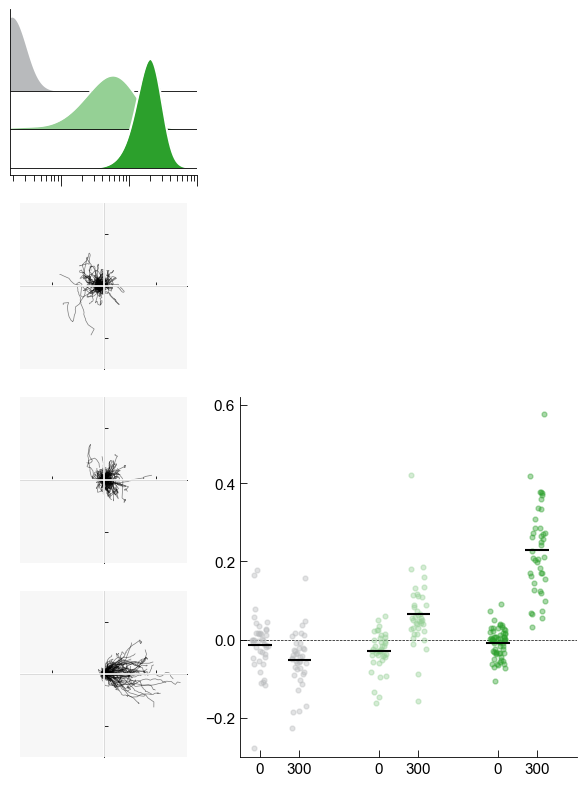

In [6]:
fig = plt.figure(figsize=(6,8))
gs = GridSpec(nrows=4, ncols=2,
              height_ratios=[1, 1, 1, 1],
              width_ratios=[1, 1.8])


###################################
# flow  cytometry
################################################
############################
############################
ax1 = fig.add_subplot(gs[0,0])

# Input files and labels
flow_files = [files[0], files[1], files[-1]]
# labels = ['CR02-high', 'CR01-low', 'WT-parental']
labels = ['MDCK +Galvanin-GFP\n(high expression)', 'MDCK +Galvanin-GFP\n(low expression)', 'MDCK']
colors = [(0.1725, 0.6274, 0.1725), (0.586, 0.814, 0.586), '#B8BABC']


offset = 0.75

x_shared = np.linspace(3.25, 6.6, 500)  # Shared x-grid
density_cutoff = 1e-3                   # Clip below this density threshold

for i, (f, label, color) in enumerate(zip(flow_files, labels, colors)):
    # Load and preprocess data
    sample = FCMeasurement(ID=label, datafile=f).data
    sample = sample[(sample['FSC-A'] >= 2.5E6) & 
                    (sample['SSC-A'] >= 0.4E5) & 
                    (sample['FSC-A'] <= 1.2E7)]
    data = sample.loc[sample['FITC-A'] > 0].copy()

    # remove doublets
    X = data[['FSC-A', 'FSC-H']].values
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X)  # add random_state for consistency
    gmm_labels = gmm.predict(X)
    
    # Count points in each cluster
    counts = Counter(gmm_labels)
    singlet_label = counts.most_common(1)[0][0]  # get label of larger cluster
    
    cluster_data = data[gmm_labels == singlet_label]

    cluster_data = cluster_data.loc[cluster_data['FITC-A'] > 0].copy()
    cluster_data['FITC-A_l'] = np.log10(cluster_data['FITC-A'])

    if cluster_data.empty:
        continue

    # KDE
    kde = gaussian_kde(cluster_data['FITC-A_l'], bw_method=0.5)
    y_vals = kde(x_shared)

    # Clip tails where density is too low
    mask = y_vals > density_cutoff
    x_clipped = x_shared[mask]
    y_clipped = y_vals[mask]

    if len(x_clipped) < 2:
        continue  # Skip if nothing left to plot

    zorder = len(flow_files) - i*2

    # Fill (zorder 1)
    ax1.fill_between(x_clipped, i * offset, i * offset + y_clipped,
                     color=color, alpha=1, zorder=zorder + 1, lw = 0)
    
    # White outline (slightly higher zorder, slightly *larger* lw)
    ax1.plot(x_clipped, i * offset + y_clipped,
             color='white', lw=1.5, zorder=zorder + 1)

    ax1.hlines(i * offset, 3.25, 6.6,  # start and end of clipped region
         color='k', lw=0.6, zorder=zorder+2)  # style to match KDE outline

    # Label
    # ax1.text(6.65, i * offset + max(y_clipped) * 0.4, label, fontsize=10, va='center', zorder=zorder + 2)


# Style
sns.despine(left=True, bottom=False)


############################
EF_dict = {'0' : 0, 
           '3' : 1}

dict_ax = {'WT-parental' : 0, 'CR01-low' : 1, 'CR02-high' : 2}
############################

ax2 = fig.add_subplot(gs[1,0])


df_temp = df_single[df_single.celltype == 'WT-parental']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['WT-parental', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax2.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax2.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 77:
        continue
    count_cell += 1
    
print(d_.celltype.unique(), count_cell)

############################

ax3 = fig.add_subplot(gs[2,0])


df_temp = df_single[df_single.celltype == 'CR01-low']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR01-low', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax3.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax3.set_ylabel(r'y position ($\mu$m)')

    if count_cell >= 77:
        continue
    count_cell += 1
    
print(d_.celltype.unique(), count_cell)

  ############################

ax4 = fig.add_subplot(gs[3,0])


df_temp = df_single[df_single.celltype == 'CR02-high']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR02-high', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax4.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax4.set_xlabel(r'x position ($\mu$m)')
    # ax4.set_ylabel(r'y position ($\mu$m)')

    if count_cell >= 77:
        continue
    count_cell += 1

print(d_.celltype.unique(), count_cell)

# Enforce identical limits explicitly
xlim = (-160, 160)
ylim = (-160, 160)

for ax_ in [ax2, ax3, ax4]:
    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    
for ax_ in [ax2, ax3, ax4]:
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)

    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    ax_.set_axisbelow(True)

for ax_ in [ax2, ax3, ax4]:
    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    # ax_.set_xlim(-400, 400)
    # ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    # Remove all tick labels
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])

    # Optional: reduce tick mark length
    ax_.tick_params(length=3)
    
############################
############################
ax5 = fig.add_subplot(gs[2:,1])

color_dict = {'WT-parental': '#B8BABC',
 'CR01-low': (0.5862745098039216, 0.8137254901960784, 0.5862745098039216),
 'CR02-high': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)}


dict_EF = {0 : 0, 
           3 : 1}

dict_x = {'WT-parental' : 0, 'CR01-low' : 3, 'CR02-high' : 6}

for sg, d_ in df_single.groupby(['celltype', 'E_V_cm']):
    dot_group = []
    dot_all = []
    for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
        dot = []
        for cell, d_cell in d.groupby('cell'):

            unique_frames = d_cell.frame.unique()
            frame_range = np.arange(d_cell.frame.min(), d_cell.frame.max() + 1)

            tot = []
            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    val = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(val)
                except IndexError:
                    print(f"Missing frame at t={t} or t-2={t-2} for cell {cell} in group {g}")
            if len(tot) > 0:
                dot.append(np.mean(tot))

                dot_all = np.append(dot_all, np.mean(tot))

    
        if len(dot) > 0:
            ax5.scatter(dict_x[sg[0]] + np.random.uniform(-0.2, 0.2) + dict_EF[sg[1]], np.mean(dot), 
                        alpha=0.4, color=color_dict[sg[0]], zorder=1, s =12)
            dot_group = np.append(dot_group, np.mean(dot))

    ax5.hlines(np.mean(dot_group), dict_x[sg[0]] + dict_EF[sg[1]] - 0.3, dict_x[sg[0]] + dict_EF[sg[1]] + 0.3, alpha=1, 
                                       color = 'k', linewidth = 1.5, zorder = 10)



ax5.set_ylim(-0.3,0.62)
ax5.set_xlim(-0.5,8)
ax5.hlines(0,-0.5, 8, linestyle = '--', linewidth = 0.5, color = 'k', zorder = 0)
# ax5.set_ylabel('average speed along electric\n'
#                 r'field direction ($\mu$m/min)')
# ax5.set_xlabel('electric field strength (mV/mm)')

# Define the tick positions and labels
xtick_positions = [0, 1, 3, 4, 6, 7]
xtick_labels = ['0', '300', '0', '300', '0', '300']

ax5.set_xticks(xtick_positions)
ax5.set_xticklabels(xtick_labels)


ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.axes.get_yaxis().set_visible(False)
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_xticklabels([])
ax1.tick_params(which='major', length=8, direction='in')
ax1.tick_params(which='minor', length=4, direction='in')
# ax1.set_xlabel('fluorescence intensity\n(Galvanin-GFP, a.u.)')

# Major ticks
ax1.set_xticks(np.log10([100, 1000, 10000, 100000, 1000000]))
# Minor ticks
ax1.set_xticks(np.log10([
    200, 300, 400, 500, 600, 700, 800, 900,
    2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000,
    20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
    200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000,
    2000000, 3000000
]), minor=True)

# Tick formatting and styling
ax1.tick_params(which='major', length=8, direction='out', bottom=True)
ax1.tick_params(which='minor', length=4, direction='out', bottom=True)

ax1.set_xlim(3.25, 6)
ax1.set_autoscale_on(False)

for spine in ax1.spines.values():
    spine.set_zorder(10)  # Increase zorder to bring to front

    
plt.tight_layout()

# plt.savefig('../../figures/20250521_MDCK_compiled_single_cells.pdf', bbox_inches='tight')

# Cell culsters (2 or more cells)

In [7]:
df_diff = df.merge(df_single, how='outer', indicator=True)
df_clusters = df_diff[df_diff['_merge'] == 'left_only'].drop(columns=['_merge'])
df_clusters.head()

,celltype,E_V_cm,date,trial,user,scope,position,cell,frame,x,y
0,CR01-low,0,20250506,0,NB,Oslo,0,3,0,520.946908,589.095950
1,CR01-low,0,20250506,0,NB,Oslo,0,3,1,519.692082,591.689040
2,CR01-low,0,20250506,0,NB,Oslo,0,3,2,519.784333,592.693157
3,CR01-low,0,20250506,0,NB,Oslo,0,3,3,519.538506,593.531422
4,CR01-low,0,20250506,0,NB,Oslo,0,3,4,520.260849,592.793850


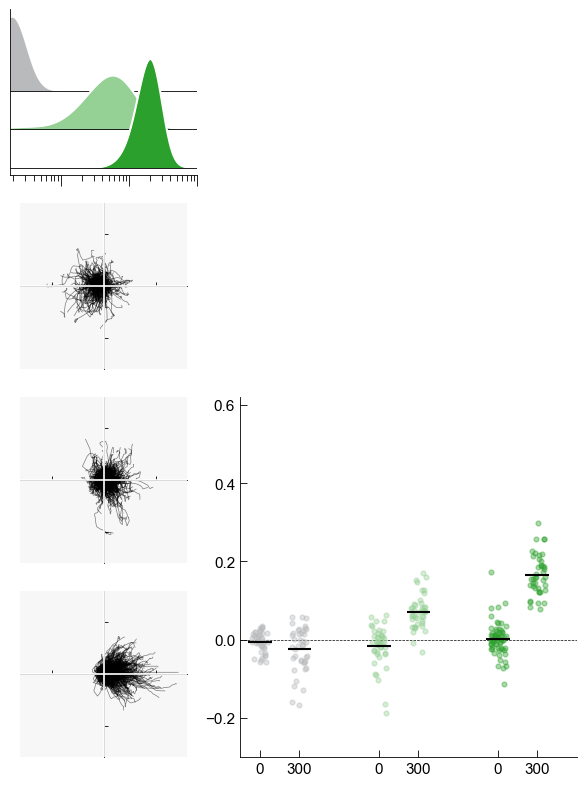

In [8]:
from matplotlib.pyplot import GridSpec
from scipy.stats import gaussian_kde
from collections import Counter

fig = plt.figure(figsize=(6,8))
gs = GridSpec(nrows=4, ncols=2,
              height_ratios=[1, 1, 1, 1],
              width_ratios=[1, 1.8])


###################################
# flow  cytometry
################################################
############################
############################
ax1 = fig.add_subplot(gs[0,0])

# Input files and labels
flow_files = [files[0], files[1], files[-1]]
# labels = ['CR02-high', 'CR01-low', 'WT-parental']
labels = ['MDCK +Galvanin-GFP\n(high expression)', 'MDCK +Galvanin-GFP\n(low expression)', 'MDCK']
colors = [(0.1725, 0.6274, 0.1725), (0.586, 0.814, 0.586), '#B8BABC']


offset = 0.75

x_shared = np.linspace(3.25, 6.6, 500)  # Shared x-grid
density_cutoff = 1e-3                   # Clip below this density threshold

for i, (f, label, color) in enumerate(zip(flow_files, labels, colors)):
    # Load and preprocess data
    sample = FCMeasurement(ID=label, datafile=f).data
    sample = sample[(sample['FSC-A'] >= 2.5E6) & 
                    (sample['SSC-A'] >= 0.4E5) & 
                    (sample['FSC-A'] <= 1.2E7)]
    data = sample.loc[sample['FITC-A'] > 0].copy()

    # remove doublets
    X = data[['FSC-A', 'FSC-H']].values
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X)  # add random_state for consistency
    gmm_labels = gmm.predict(X)
    
    # Count points in each cluster
    counts = Counter(gmm_labels)
    singlet_label = counts.most_common(1)[0][0]  # get label of larger cluster
    
    cluster_data = data[gmm_labels == singlet_label]

    cluster_data = cluster_data.loc[cluster_data['FITC-A'] > 0].copy()
    cluster_data['FITC-A_l'] = np.log10(cluster_data['FITC-A'])

    if cluster_data.empty:
        continue

    # KDE
    kde = gaussian_kde(cluster_data['FITC-A_l'], bw_method=0.5)
    y_vals = kde(x_shared)

    # Clip tails where density is too low
    mask = y_vals > density_cutoff
    x_clipped = x_shared[mask]
    y_clipped = y_vals[mask]

    if len(x_clipped) < 2:
        continue  # Skip if nothing left to plot

    zorder = len(flow_files) - i*2

    # Fill (zorder 1)
    ax1.fill_between(x_clipped, i * offset, i * offset + y_clipped,
                     color=color, alpha=1, zorder=zorder + 1, lw = 0)
    
    # White outline (slightly higher zorder, slightly *larger* lw)
    ax1.plot(x_clipped, i * offset + y_clipped,
             color='white', lw=1.5, zorder=zorder + 1)

    ax1.hlines(i * offset, 3.25, 6.6,  # start and end of clipped region
         color='k', lw=0.6, zorder=zorder+2)  # style to match KDE outline

    # Label
    # ax1.text(6.65, i * offset + max(y_clipped) * 0.4, label, fontsize=10, va='center', zorder=zorder + 2)


# Style
sns.despine(left=True, bottom=False)


############################
EF_dict = {'0' : 0, 
           '3' : 1}

dict_ax = {'WT-parental' : 0, 'CR01-low' : 1, 'CR02-high' : 2}
############################

ax2 = fig.add_subplot(gs[1,0])


df_temp = df_clusters[df_clusters.celltype == 'WT-parental']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['WT-parental', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax2.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax2.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

############################

ax3 = fig.add_subplot(gs[2,0])


df_temp = df_clusters[df_clusters.celltype == 'CR01-low']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR01-low', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax3.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax3.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1
    
  ############################

ax4 = fig.add_subplot(gs[3,0])


df_temp = df_clusters[df_clusters.celltype == 'CR02-high']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR02-high', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax4.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax4.set_xlabel(r'x position ($\mu$m)')
    # ax4.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

# Enforce identical limits explicitly
xlim = (-160, 160)
ylim = (-160, 160)

for ax_ in [ax2, ax3, ax4]:
    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    
for ax_ in [ax2, ax3, ax4]:
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)

    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    ax_.set_axisbelow(True)

for ax_ in [ax2, ax3, ax4]:
    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    # ax_.set_xlim(-400, 400)
    # ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    # Remove all tick labels
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])

    # Optional: reduce tick mark length
    ax_.tick_params(length=3)
    
############################
############################
ax5 = fig.add_subplot(gs[2:,1])

color_dict = {'WT-parental': '#B8BABC',
 'CR01-low': (0.5862745098039216, 0.8137254901960784, 0.5862745098039216),
 'CR02-high': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)}


dict_EF = {0 : 0, 
           3 : 1}

dict_x = {'WT-parental' : 0, 'CR01-low' : 3, 'CR02-high' : 6}

for sg, d_ in df_clusters.groupby(['celltype', 'E_V_cm']):
    dot_group = []
    dot_all = []
    for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
        dot = []
        for cell, d_cell in d.groupby('cell'):

            unique_frames = d_cell.frame.unique()
            frame_range = np.arange(d_cell.frame.min(), d_cell.frame.max() + 1)

            tot = []
            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    val = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(val)
                except IndexError:
                    print(f"Missing frame at t={t} or t-2={t-2} for cell {cell} in group {g}")
            if len(tot) > 0:
                dot.append(np.mean(tot))

                dot_all = np.append(dot_all, np.mean(tot))

    
        if len(dot) > 0:
            ax5.scatter(dict_x[sg[0]] + np.random.uniform(-0.2, 0.2) + dict_EF[sg[1]], np.mean(dot), 
                        alpha=0.4, color=color_dict[sg[0]], zorder=1, s =12)
            dot_group = np.append(dot_group, np.mean(dot))

    ax5.hlines(np.mean(dot_group), dict_x[sg[0]] + dict_EF[sg[1]] - 0.3, dict_x[sg[0]] + dict_EF[sg[1]] + 0.3, alpha=1, 
                                       color = 'k', linewidth = 1.5, zorder = 10)


ax5.set_ylim(-0.3,0.62)
ax5.set_xlim(-0.5,8)
ax5.hlines(0,-0.5, 8, linestyle = '--', linewidth = 0.5, color = 'k', zorder = 0)
# ax5.set_ylabel('average speed along electric\n'
#                 r'field direction ($\mu$m/min)')
# ax5.set_xlabel('electric field strength (mV/mm)')

# Define the tick positions and labels
xtick_positions = [0, 1, 3, 4, 6, 7]
xtick_labels = ['0', '300', '0', '300', '0', '300']

ax5.set_xticks(xtick_positions)
ax5.set_xticklabels(xtick_labels)


ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.axes.get_yaxis().set_visible(False)
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_xticklabels([])
ax1.tick_params(which='major', length=8, direction='in')
ax1.tick_params(which='minor', length=4, direction='in')
# ax1.set_xlabel('fluorescence intensity\n(Galvanin-GFP, a.u.)')

# Major ticks
ax1.set_xticks(np.log10([100, 1000, 10000, 100000, 1000000]))
# Minor ticks
ax1.set_xticks(np.log10([
    200, 300, 400, 500, 600, 700, 800, 900,
    2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000,
    20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
    200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000,
    2000000, 3000000
]), minor=True)

# Tick formatting and styling
ax1.tick_params(which='major', length=8, direction='out', bottom=True)
ax1.tick_params(which='minor', length=4, direction='out', bottom=True)

ax1.set_xlim(3.25, 6)
ax1.set_autoscale_on(False)

for spine in ax1.spines.values():
    spine.set_zorder(10)  # Increase zorder to bring to front

    
plt.tight_layout()

plt.savefig('../../figures/20250521_MDCK_compiled_cellclusters.pdf', bbox_inches='tight')

# Statistics

In [9]:
# all the data
from scipy.stats import mannwhitneyu

# Create data container to store dot values per group
speed_dict = {}

# Group and extract mean dx speed per trial-level replicate
for (celltype, E_field), df_group in df.groupby(['celltype', 'E_V_cm']):
    key = (E_field, celltype)
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue  # skip missing frame pairs

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_dict[key] = trial_means

# Get list of all E field strengths
all_E_fields = sorted({k[0] for k in speed_dict.keys()})

# Perform pairwise comparisons at each E field
for E in all_E_fields:
    print(f"\nE = {E} V/cm")
    
    try:
        a = speed_dict[(E, 'WT-parental')]
        b = speed_dict[(E, 'CR01-low')]
        c = speed_dict[(E, 'CR02-high')]
    except KeyError:
        print("  Missing one or more groups.")
        continue

    # WT vs CR01
    try:
        res_ab = mannwhitneyu(a, b, alternative='two-sided')
        print(f"  WT vs CR01: p = {res_ab.pvalue:.4f}, n = {len(a)} vs {len(b)}")
    except:
        print("  WT vs CR01: insufficient data")

    # WT vs CR02
    try:
        res_ac = mannwhitneyu(a, c, alternative='two-sided')
        print(f"  WT vs CR02: p = {res_ac.pvalue:.4f}, n = {len(a)} vs {len(c)}")
    except:
        print("  WT vs CR02: insufficient data")

    # CR01 vs CR02
    try:
        res_bc = mannwhitneyu(b, c, alternative='two-sided')
        print(f"  CR01 vs CR02: p = {res_bc.pvalue:.4f}, n = {len(b)} vs {len(c)}")
    except:
        print("  CR01 vs CR02: insufficient data")


##################################
##################################
# Compare within each cell type (compare EF conditions) 
##################################
##################################

from itertools import combinations

# Organize data: for each (celltype, E_V_cm), collect trial-level means
speed_by_field = {}

for (celltype, E_field), df_group in df.groupby(['celltype', 'E_V_cm']):
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_by_field[(celltype, E_field)] = trial_means

# Extract all cell types and E-field conditions present
celltypes = sorted({key[0] for key in speed_by_field})
E_fields = sorted({key[1] for key in speed_by_field})

# Compare all pairs of E fields within each cell type
for celltype in celltypes:
    print(f"\n📊 Comparisons for cell type: {celltype}")

    available_fields = sorted([E for (ct, E) in speed_by_field if ct == celltype])
    for E1, E2 in combinations(available_fields, 2):
        group1 = speed_by_field.get((celltype, E1), [])
        group2 = speed_by_field.get((celltype, E2), [])

        if len(group1) > 0 and len(group2) > 0:
            res = mannwhitneyu(group1, group2, alternative='two-sided')
            print(f"  {E1} vs {E2} V/cm: p = {res.pvalue:.4f} (n={len(group1)} vs {len(group2)})")
        else:
            print(f"  {E1} vs {E2} V/cm: insufficient data")


E = 0 V/cm
  WT vs CR01: p = 0.2970, n = 41 vs 42
  WT vs CR02: p = 0.3088, n = 41 vs 63
  CR01 vs CR02: p = 0.0637, n = 42 vs 63

E = 3 V/cm
  WT vs CR01: p = 0.0000, n = 41 vs 42
  WT vs CR02: p = 0.0000, n = 41 vs 42
  CR01 vs CR02: p = 0.0000, n = 42 vs 42

📊 Comparisons for cell type: CR01-low
  0 vs 3 V/cm: p = 0.0000 (n=42 vs 42)

📊 Comparisons for cell type: CR02-high
  0 vs 3 V/cm: p = 0.0000 (n=63 vs 42)

📊 Comparisons for cell type: WT-parental
  0 vs 3 V/cm: p = 0.1170 (n=41 vs 41)


In [10]:
# single cells

# Create data container to store dot values per group
speed_dict = {}

# Group and extract mean dx speed per trial-level replicate
for (celltype, E_field), df_group in df_single.groupby(['celltype', 'E_V_cm']):
    key = (E_field, celltype)
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue  # skip missing frame pairs

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_dict[key] = trial_means

# Get list of all E field strengths
all_E_fields = sorted({k[0] for k in speed_dict.keys()})

# Perform pairwise comparisons at each E field
for E in all_E_fields:
    print(f"\nE = {E} V/cm")
    
    try:
        a = speed_dict[(E, 'WT-parental')]
        b = speed_dict[(E, 'CR01-low')]
        c = speed_dict[(E, 'CR02-high')]
    except KeyError:
        print("  Missing one or more groups.")
        continue

    # WT vs CR01
    try:
        res_ab = mannwhitneyu(a, b, alternative='two-sided')
        print(f"  WT vs CR01: p = {res_ab.pvalue:.4f}, n = {len(a)} vs {len(b)}")
    except:
        print("  WT vs CR01: insufficient data")

    # WT vs CR02
    try:
        res_ac = mannwhitneyu(a, c, alternative='two-sided')
        print(f"  WT vs CR02: p = {res_ac.pvalue:.4f}, n = {len(a)} vs {len(c)}")
    except:
        print("  WT vs CR02: insufficient data")

    # CR01 vs CR02
    try:
        res_bc = mannwhitneyu(b, c, alternative='two-sided')
        print(f"  CR01 vs CR02: p = {res_bc.pvalue:.4f}, n = {len(b)} vs {len(c)}")
    except:
        print("  CR01 vs CR02: insufficient data")



from itertools import combinations

# Organize data: for each (celltype, E_V_cm), collect trial-level means
speed_by_field = {}

for (celltype, E_field), df_group in df_single.groupby(['celltype', 'E_V_cm']):
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_by_field[(celltype, E_field)] = trial_means

# Extract all cell types and E-field conditions present
celltypes = sorted({key[0] for key in speed_by_field})
E_fields = sorted({key[1] for key in speed_by_field})

# Compare all pairs of E fields within each cell type
for celltype in celltypes:
    print(f"\n📊 Comparisons for cell type: {celltype}")

    available_fields = sorted([E for (ct, E) in speed_by_field if ct == celltype])
    for E1, E2 in combinations(available_fields, 2):
        group1 = speed_by_field.get((celltype, E1), [])
        group2 = speed_by_field.get((celltype, E2), [])

        if len(group1) > 0 and len(group2) > 0:
            res = mannwhitneyu(group1, group2, alternative='two-sided')
            print(f"  {E1} vs {E2} V/cm: p = {res.pvalue:.4f} (n={len(group1)} vs {len(group2)})")
        else:
            print(f"  {E1} vs {E2} V/cm: insufficient data")


E = 0 V/cm
  WT vs CR01: p = 0.1368, n = 41 vs 40
  WT vs CR02: p = 0.7095, n = 41 vs 63
  CR01 vs CR02: p = 0.0306, n = 40 vs 63

E = 3 V/cm
  WT vs CR01: p = 0.0000, n = 39 vs 39
  WT vs CR02: p = 0.0000, n = 39 vs 42
  CR01 vs CR02: p = 0.0000, n = 39 vs 42

📊 Comparisons for cell type: CR01-low
  0 vs 3 V/cm: p = 0.0000 (n=40 vs 39)

📊 Comparisons for cell type: CR02-high
  0 vs 3 V/cm: p = 0.0000 (n=63 vs 42)

📊 Comparisons for cell type: WT-parental
  0 vs 3 V/cm: p = 0.0032 (n=41 vs 39)


In [11]:
# cell clusters

# Create data container to store dot values per group
speed_dict = {}

# Group and extract mean dx speed per trial-level replicate
for (celltype, E_field), df_group in df_clusters.groupby(['celltype', 'E_V_cm']):
    key = (E_field, celltype)
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue  # skip missing frame pairs

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_dict[key] = trial_means

# Get list of all E field strengths
all_E_fields = sorted({k[0] for k in speed_dict.keys()})

# Perform pairwise comparisons at each E field
for E in all_E_fields:
    print(f"\nE = {E} V/cm")
    
    try:
        a = speed_dict[(E, 'WT-parental')]
        b = speed_dict[(E, 'CR01-low')]
        c = speed_dict[(E, 'CR02-high')]
    except KeyError:
        print("  Missing one or more groups.")
        continue

    # WT vs CR01
    try:
        res_ab = mannwhitneyu(a, b, alternative='two-sided')
        print(f"  WT vs CR01: p = {res_ab.pvalue:.4f}, n = {len(a)} vs {len(b)}")
    except:
        print("  WT vs CR01: insufficient data")

    # WT vs CR02
    try:
        res_ac = mannwhitneyu(a, c, alternative='two-sided')
        print(f"  WT vs CR02: p = {res_ac.pvalue:.4f}, n = {len(a)} vs {len(c)}")
    except:
        print("  WT vs CR02: insufficient data")

    # CR01 vs CR02
    try:
        res_bc = mannwhitneyu(b, c, alternative='two-sided')
        print(f"  CR01 vs CR02: p = {res_bc.pvalue:.4f}, n = {len(b)} vs {len(c)}")
    except:
        print("  CR01 vs CR02: insufficient data")


from itertools import combinations

# Organize data: for each (celltype, E_V_cm), collect trial-level means
speed_by_field = {}

for (celltype, E_field), df_group in df_clusters.groupby(['celltype', 'E_V_cm']):
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_by_field[(celltype, E_field)] = trial_means

# Extract all cell types and E-field conditions present
celltypes = sorted({key[0] for key in speed_by_field})
E_fields = sorted({key[1] for key in speed_by_field})

# Compare all pairs of E fields within each cell type
for celltype in celltypes:
    print(f"\n📊 Comparisons for cell type: {celltype}")

    available_fields = sorted([E for (ct, E) in speed_by_field if ct == celltype])
    for E1, E2 in combinations(available_fields, 2):
        group1 = speed_by_field.get((celltype, E1), [])
        group2 = speed_by_field.get((celltype, E2), [])

        if len(group1) > 0 and len(group2) > 0:
            res = mannwhitneyu(group1, group2, alternative='two-sided')
            print(f"  {E1} vs {E2} V/cm: p = {res.pvalue:.4f} (n={len(group1)} vs {len(group2)})")
        else:
            print(f"  {E1} vs {E2} V/cm: insufficient data")


E = 0 V/cm
  WT vs CR01: p = 0.4974, n = 41 vs 42
  WT vs CR02: p = 0.4248, n = 41 vs 63
  CR01 vs CR02: p = 0.1456, n = 42 vs 63

E = 3 V/cm
  WT vs CR01: p = 0.0000, n = 41 vs 42
  WT vs CR02: p = 0.0000, n = 41 vs 42
  CR01 vs CR02: p = 0.0000, n = 42 vs 42

📊 Comparisons for cell type: CR01-low
  0 vs 3 V/cm: p = 0.0000 (n=42 vs 42)

📊 Comparisons for cell type: CR02-high
  0 vs 3 V/cm: p = 0.0000 (n=63 vs 42)

📊 Comparisons for cell type: WT-parental
  0 vs 3 V/cm: p = 0.2316 (n=41 vs 41)


## Summary of cell numbers and replcates

In [12]:
df

,celltype,E_V_cm,date,trial,user,scope,position,cell,frame,x,y
0,CR01-low,0,20250506,0,NB,Oslo,0,3,0,520.946908,589.095950
1,CR01-low,0,20250506,0,NB,Oslo,0,3,1,519.692082,591.689040
2,CR01-low,0,20250506,0,NB,Oslo,0,3,2,519.784333,592.693157
3,CR01-low,0,20250506,0,NB,Oslo,0,3,3,519.538506,593.531422
4,CR01-low,0,20250506,0,NB,Oslo,0,3,4,520.260849,592.793850
...,...,...,...,...,...,...,...,...,...,...,...
235027,WT-parental,3,20250507,0,NB,Rio,20,23,15,259.726605,240.578469
235028,WT-parental,3,20250507,0,NB,Rio,20,23,16,256.729621,240.548348
235029,WT-parental,3,20250507,0,NB,Rio,20,23,17,255.050055,241.348840
235030,WT-parental,3,20250507,0,NB,Rio,20,23,18,254.888356,243.428028


In [13]:
# Create a new global unique cell ID per group
df['cell_global'] = (
    df['date'].astype(str) + '_' +
    df['celltype'].astype(str) + '_' +
    df['trial'].astype(str) + '_' +
    df['user'].astype(str) + '_' +
    df['position'].astype(str) + '_' +
    df['cell'].astype(str)
)

# Group and count
summary_stats = []
for (celltype, E_V_cm), df_group in df.groupby(['celltype', 'E_V_cm']):
    n_samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    n_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': n_samples,
        'n_cells': n_cells
    })

df_summary_stats = pd.DataFrame(summary_stats).sort_values(['celltype', 'E_V_cm'])
df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,CR01-low,0,2,971
1,CR01-low,3,2,1105
2,CR02-high,0,3,1768
3,CR02-high,3,2,1507
4,WT-parental,0,2,1364
5,WT-parental,3,2,1396


In [14]:
# Create a new global unique cell ID per group
df_single['cell_global'] = (
    df_single['date'].astype(str) + '_' +
    df_single['celltype'].astype(str) + '_' +
    df_single['trial'].astype(str) + '_' +
    df_single['user'].astype(str) + '_' +
    df_single['position'].astype(str) + '_' +
    df_single['cell'].astype(str)
)

# Group and count
summary_stats = []
for (celltype, E_V_cm), df_group in df_single.groupby(['celltype', 'E_V_cm']):
    n_samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    n_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': n_samples,
        'n_cells': n_cells
    })

df_summary_stats = pd.DataFrame(summary_stats).sort_values(['celltype', 'E_V_cm'])
df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,CR01-low,0,2,212
1,CR01-low,3,2,157
2,CR02-high,0,3,404
3,CR02-high,3,2,217
4,WT-parental,0,2,199
5,WT-parental,3,2,163


In [15]:
# Create a new global unique cell ID per group
df_clusters['cell_global'] = (
    df_clusters['date'].astype(str) + '_' +
    df_clusters['celltype'].astype(str) + '_' +
    df_clusters['trial'].astype(str) + '_' +
    df_clusters['user'].astype(str) + '_' +
    df_clusters['position'].astype(str) + '_' +
    df_clusters['cell'].astype(str)
)

# Group and count
summary_stats = []
for (celltype, E_V_cm), df_group in df_clusters.groupby(['celltype', 'E_V_cm']):
    n_samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    n_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': n_samples,
        'n_cells': n_cells
    })

df_summary_stats = pd.DataFrame(summary_stats).sort_values(['celltype', 'E_V_cm'])
df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,CR01-low,0,2,759
1,CR01-low,3,2,948
2,CR02-high,0,3,1364
3,CR02-high,3,2,1290
4,WT-parental,0,2,1165
5,WT-parental,3,2,1233
